# Лабораторная работа 1

по курсу: "Киберфизические системы"

Выполнила Ирина Владимировна Сектименко, студент группы М8О-410Б-22

## Выбор начальных условий

Для решения задачи классификации был выбран датасет с сайта kaggle.com.

Ссылка на датасет: https://www.kaggle.com/datasets/shashwatwork/fruitnet-indian-fruits-dataset-with-quality/data

Описание датасета: набор данных состоит из 14700+ высококачественных изображений 6 различных классов фруктов (яблоко, банан, гуава, лайм, апельсин и гранат), разделенных на 3 группы качества фруктов (хорошее, плохое и смешанное качество).

Практическая ососнованность: вручную сортировать тонны фруктов дорого, медленно. Автоматическая сортировка снижает затраты и повышает эффективность. Например, после полета дрона над садом известно, сколько процентов фруктов уже готово к сбору, какие деревья дают много брака.

In [1]:
!pip install kagglehub

In [2]:
import kagglehub
from google.colab import userdata


kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [3]:
path = kagglehub.dataset_download("shashwatwork/fruitnet-indian-fruits-dataset-with-quality")

print(f"Датасет загружен в: {path}")

Using Colab cache for faster access to the 'fruitnet-indian-fruits-dataset-with-quality' dataset.
Датасет загружен в: /kaggle/input/fruitnet-indian-fruits-dataset-with-quality


In [4]:
import shutil

In [7]:
target_path = "/content/fruitnet_dataset"
shutil.copytree(path, target_path)

'/content/fruitnet_dataset'

Для оценки качества классификации моделью будут использоваться следующие метрики: accuracy (общая точность предсказаний), precision (точность предсказаний конкретного класса), recall (полнота предсказаний класса) и F1-score (метрика, которая учитывает precision и recall) для каждого класса по отдельности. Суммарное качество классификации по двум последним метрикам будет оцениваться как среднее значение.


## Сверточная модель

### Создание бейзлайна и оценка качества модели

Подготовка датасета

Преобразование структуры датасета из иерархической в "плоскую". Так попка "Bad Qualiry_Fruits" с 6-ю папками разных фруктов внутри преобразуется просто в 6 папок с типовым названием "Bad <название фрукта>". Именно с такой структурой работает модель.

In [8]:
import os

In [9]:
source_path = "/content/fruitnet_dataset/Processed Images_Fruits"

target_path = "/content/dataset_fruit"

os.makedirs(target_path, exist_ok=True)

for main_folder in os.listdir(source_path):
    source_path_dir = os.path.join(source_path, main_folder)
    for folder in os.listdir(source_path_dir):
        source_folder = os.path.join(source_path_dir, folder)
        target_folder = os.path.join(target_path, folder)

        shutil.copytree(source_folder, target_folder)

Определим минимальную ширину и высоту всех изображений, чтобы впоследствии подогнать все изображения к одному максимально возможному размеру без потери качества.

In [ ]:
from PIL import Image
from pathlib import Path

In [ ]:
dataset_path = "/content/dataset_fruit"

# до этого было просмотрено пару фотографий, их размеры точно меньше заданных минимальных
min_width = 1024
min_height = 1024

total_images = 0
error_images = 0

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        file_path = os.path.join(root, file)
        with Image.open(file_path) as img:
            width, height = img.size

            if width < min_width:
                min_width = width
            if height < min_height:
                min_height = height

print(min_width, min_height)

144 144


In [10]:
import torch

In [11]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [12]:
from torchvision import datasets, transforms
from collections import Counter
from torch.utils.data import DataLoader, random_split

In [11]:
IMAGE_SIZE = 144
BATCH_SIZE = 32
NUM_EPOCHS = 5
LEARNING_RATE = 0.001

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(target_path, transform=train_transforms)

class_counts = Counter([full_dataset.classes[idx] for i, idx in full_dataset.samples])
print("Распределение по классам:")
for class_name, count in sorted(class_counts.items()):
    print(f"  {class_name}: {count} изображений")

Распределение по классам:
  Apple: 113 изображений
  Apple_Bad: 1141 изображений
  Apple_Good: 1149 изображений
  Banana: 285 изображений
  Banana_Bad: 1087 изображений
  Banana_Good: 1113 изображений
  Guava: 148 изображений
  Guava_Bad: 1129 изображений
  Guava_Good: 1152 изображений
  Lemon: 278 изображений
  Lime_Bad: 1085 изображений
  Lime_Good: 1094 изображений
  Orange: 125 изображений
  Orange_Bad: 1159 изображений
  Orange_Good: 1216 изображений
  Pomegranate: 125 изображений
  Pomegranate_Bad: 1187 изображений
  Pomegranate_Good: 5940 изображений


In [12]:
# Разделение датасета: 70% train, 15% val, 15% test
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

train_dataset.dataset.transform = train_transforms
val_dataset.dataset.transform = val_transforms
test_dataset.dataset.transform = val_transforms

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Размеры выборок:")
print(f"Train: {train_size}")
print(f"Val: {val_size}")
print(f"Test: {test_size}")
print(f"\nКлассов: {int(len(full_dataset.classes))}")

Размеры выборок:
Train: 13668
Val: 2928
Test: 2930

Классов: 18


Создание и обучение модели ResNet18 со случайными начальными весами (не предобученная).

In [16]:
import torch.nn as nn
from torchvision import models
import torch.optim as optim
import time

In [15]:
num_classes = len(full_dataset.classes)

In [ ]:
model = models.resnet18(pretrained=False)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
criterion = nn.CrossEntropyLoss()  # функция потерь для многоклассовой классификации
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# История обучения
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_acc = 0.0
best_model_path = '/content/models/best_resnet18_random.pth'
os.makedirs('/content/models', exist_ok=True)

print("Начало обучения ResNet18 со случайными весами...\n")
start_time = time.time()

for epoch in range(NUM_EPOCHS):

    # Обучение
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss, train_acc = running_loss / len(train_loader), 100.0 * correct / total

    # Валидация
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss, val_acc = running_loss / len(val_loader), 100.0 * correct / total

    # Сохранение истории
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]\n"
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%\n"
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

training_time = time.time() - start_time
print(f"\nОбучение завершено за {training_time/60:.2f} минут")

Начало обучения ResNet18 со случайными весами...

Epoch [1/5]
Train Loss: 0.8739, Train Acc: 72.85%
Val Loss: 1.0042, Val Acc: 72.92%
Epoch [2/5]
Train Loss: 0.4844, Train Acc: 84.75%
Val Loss: 0.8653, Val Acc: 74.69%
Epoch [3/5]
Train Loss: 0.3444, Train Acc: 88.62%
Val Loss: 0.2946, Val Acc: 90.51%
Epoch [4/5]
Train Loss: 0.2879, Train Acc: 90.69%
Val Loss: 1.0135, Val Acc: 73.29%
Epoch [5/5]
Train Loss: 0.2813, Train Acc: 90.67%
Val Loss: 0.3862, Val Acc: 86.99%

Обучение завершено за 13.04 минут


Лучший результат на валидационной выборке показала модель на 3-ей эпохе. После резко улучшилось качество модели: уменьшилась ошибка (loss) и увеличилась точность (accurancy) - на тренировочной выборке и учудшилось качество модели на валидационной, что может свидетельствовать о переобучении.

Тестирование лучшего варианта (3-я эпоха) модели на тестовой выборке.

In [17]:
from sklearn.metrics import classification_report

In [ ]:
model.load_state_dict(torch.load(best_model_path))

model.eval()
running_loss = 0.0
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss, test_acc, test_preds, test_labels = running_loss / len(test_loader), \
                                               100. * correct / total, \
                                               all_preds, all_labels

print(f"Ошибка потерь (loss): {test_loss:.4f}")
print(f"Точность (accuracy): {test_acc:.2f}%")

class_names = full_dataset.classes
print("Отчет по классам:")
print(classification_report(test_labels, test_preds, target_names=class_names, digits=3))

Ошибка потерь (loss): 0.3248
Точность (accuracy): 89.39%
Отчет по классам:
                  precision    recall  f1-score   support

           Apple      0.652     0.833     0.732        18
       Apple_Bad      0.839     0.897     0.867       174
      Apple_Good      0.923     0.720     0.809       182
          Banana      0.682     0.357     0.469        42
      Banana_Bad      0.970     0.959     0.965       171
     Banana_Good      0.733     1.000     0.846       178
           Guava      0.420     0.700     0.525        30
       Guava_Bad      0.980     0.880     0.927       166
      Guava_Good      0.959     0.757     0.846       185
           Lemon      0.812     0.351     0.491        37
        Lime_Bad      0.845     0.870     0.857       169
       Lime_Good      0.800     0.970     0.877       169
          Orange      0.706     0.522     0.600        23
      Orange_Bad      0.981     0.839     0.904       180
     Orange_Good      0.878     0.912     0.895       

В среднем модель показала хороший результат на тестовой выборке. Можно заметить, что хушие метрики (F1-score около 0.5) у классов Apple, Banana, Guava и т.д., которые относятся к Mixed-quality и имеют наименьший набор данных (картинок в 2-3 разам меньше, чем у остальных классов).

Метрика precision говорит о том, что объекты других классов попадают в нужный по ошибке. Если метрика < 0.5, то модель сильно путает объекты разных классов.

Метрика recall говорит о том, что не все объекты класса были отнесены к классу, то есть о полноте предсказания. Если метрика < 0.5, то модель зачастую относит объект к какому-то другому классу, а не к нужному.

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

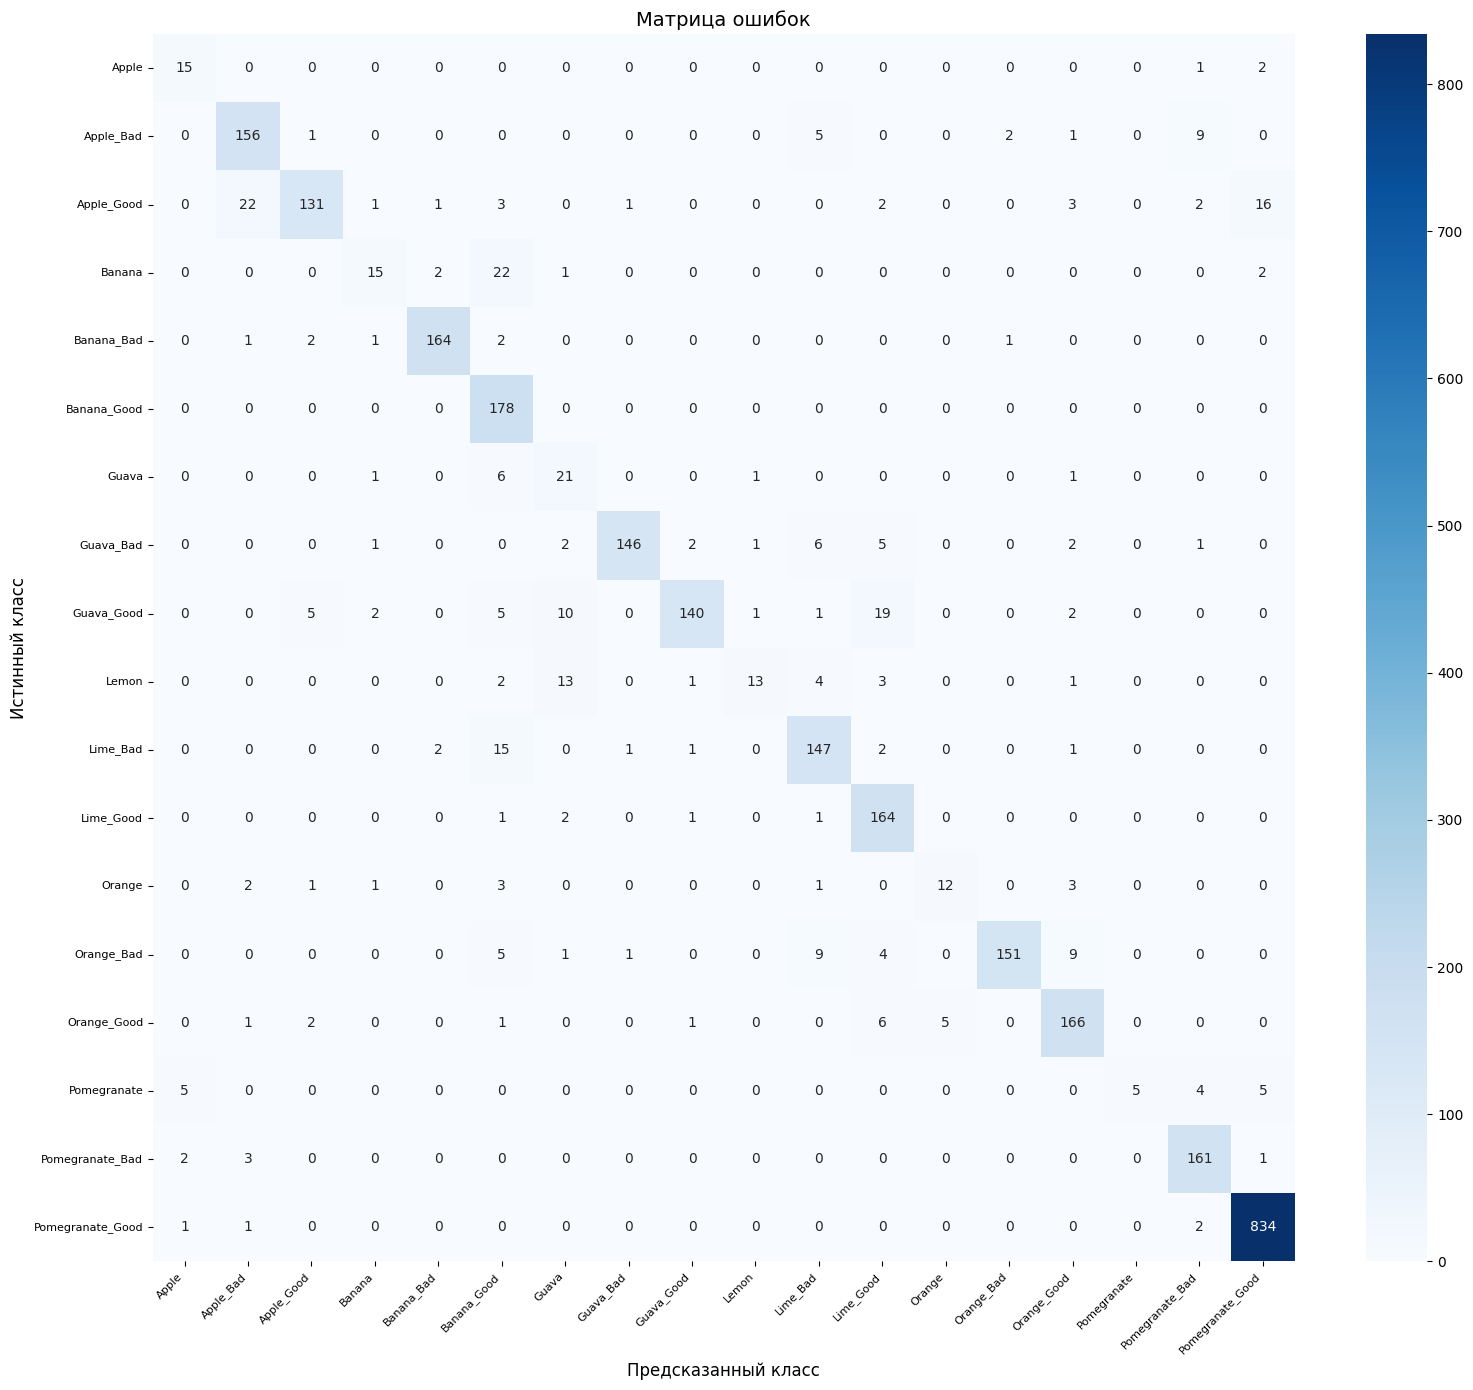

In [ ]:
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.ylabel('Истинный класс', fontsize=12)
plt.title('Матрица ошибок', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

По построенному графику (hitmap) можно сделать вывод, что преимущественно модель правильно распределяет объекты по классам.

### Улучшение бейзлайна

Для улучшения бейзлайна можно поработать с датасетом и/или гиперпараметрами модели.

#### Гипотеза 1

Просмотрев датасет, можно заметить, что в нем есть повторяющиеся изображения: разница в нескольких градусов поворота фрукта вокруг своей оси или в небольшом смещении камеры по вертикали или горизонтали.

Проведем аугментацию данных, чтобы нейросеть не запоминала каждое конкретное изображение, а запоминала отличительные признаки каждого фрукта.

In [15]:
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomAffine(
        degrees=30,           # борьба с конкретным поворотом
        translate=(0.2, 0.2), # сдвиг положения камеры по вертикале и горизонтали
        fill=0
    ),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # масштабирование, борьба с запоминанием размера
    transforms.RandomHorizontalFlip(p=0.5), # горизонтальное отображение
    transforms.ColorJitter( # борьба с конкретными цветовыми характеристиками
        brightness=0.3,  # яркость
        saturation=0.3,  # насыщенность
        hue=0.1          # оттенок
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # нормализация значений пикселя около нуля
                        std=[0.229, 0.224, 0.225])
])

Повторим все действия по обучению модели, как в пункте по создания базового бейзлайна.

In [16]:
train_dataset.dataset.transform = train_transforms

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

In [ ]:
model = models.resnet18(pretrained=False)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
criterion = nn.CrossEntropyLoss()  # функция потерь для многоклассовой классификации
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# История обучения
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_acc = 0.0
best_model_path = '/content/models/best_resnet18_random.pth'
os.makedirs('/content/models', exist_ok=True)

print("Начало обучения ResNet18 со случайными весами...\n")
start_time = time.time()

for epoch in range(NUM_EPOCHS):

    # Обучение
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss, train_acc = running_loss / len(train_loader), 100.0 * correct / total

    # Валидация
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss, val_acc = running_loss / len(val_loader), 100.0 * correct / total

    # Сохранение истории
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]\n"
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%\n"
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

training_time = time.time() - start_time
print(f"\nОбучение завершено за {training_time/60:.2f} минут")

Начало обучения ResNet18 со случайными весами...

Epoch [1/5]
Train Loss: 0.9309, Train Acc: 71.29%
Val Loss: 1.1286, Val Acc: 67.38%
Epoch [2/5]
Train Loss: 0.4816, Train Acc: 84.08%
Val Loss: 0.8994, Val Acc: 73.87%
Epoch [3/5]
Train Loss: 0.3655, Train Acc: 87.64%
Val Loss: 0.4328, Val Acc: 84.84%
Epoch [4/5]
Train Loss: 0.3012, Train Acc: 89.95%
Val Loss: 0.2824, Val Acc: 90.61%
Epoch [5/5]
Train Loss: 0.2631, Train Acc: 91.46%
Val Loss: 0.5358, Val Acc: 82.04%

Обучение завершено за 13.68 минут


На первых 3-ех эпохах обучения результаты немного ухудшились (loss на сотые, accurancy на несколько процентов).

Однако на 4-ой эпохе удалось избежать переобучения ("отложить" до 5-ой эпохи), так как результаты не сильно ухудшились, как в базовой бейзлайне, а даже немного улучшились, как на тренировочном, так и на валидационном датасете.

Протестируем полученную обученную модель и посмотрим, что с метриками на малочисленных классах из папки "Mixed fruits"

In [ ]:
model.load_state_dict(torch.load(best_model_path))

model.eval()
running_loss = 0.0
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss, test_acc, test_preds, test_labels = running_loss / len(test_loader), \
                                               100. * correct / total, \
                                               all_preds, all_labels

print(f"Ошибка потерь (loss): {test_loss:.4f}")
print(f"Точность (accuracy): {test_acc:.2f}%")

class_names = full_dataset.classes
print("Отчет по классам:")
print(classification_report(test_labels, test_preds, target_names=class_names, digits=3))

Ошибка потерь (loss): 0.2547
Точность (accuracy): 92.15%
Отчет по классам:
                  precision    recall  f1-score   support

           Apple      0.867     0.812     0.839        16
       Apple_Bad      0.926     0.906     0.916       180
      Apple_Good      0.870     0.828     0.848       169
          Banana      0.595     0.806     0.685        31
      Banana_Bad      0.987     0.911     0.948       169
     Banana_Good      0.980     0.936     0.957       156
           Guava      0.857     0.286     0.429        21
       Guava_Bad      0.981     0.909     0.944       175
      Guava_Good      0.893     0.918     0.905       146
           Lemon      0.750     0.675     0.711        40
        Lime_Bad      0.936     0.820     0.874       178
       Lime_Good      0.968     0.944     0.956       162
          Orange      0.471     0.615     0.533        13
      Orange_Bad      0.756     0.963     0.847       190
     Orange_Good      0.831     0.940     0.882       

В среднем метрики улучшились, однако проблема с малочисленными классами сохранилась.

#### Гипотеза 2

Преимущественно модель ошибается в малочисленных классах.

Чтобы этого избежать, создадим сэмплер, который будет на каждой эпохе чаще выбирать объекты из малочисленных классов.

In [ ]:
from torch.utils.data import WeightedRandomSampler

In [ ]:
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

train_indexes = train_dataset.indices

train_labels = [full_dataset.samples[i][1] for i in train_indexes]
class_counts = Counter(train_labels)
class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights = [class_weights[label] for label in train_labels]

my_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_dataset = datasets.ImageFolder(target_path, transform=train_transforms)
train_dataset = torch.utils.data.Subset(train_dataset, train_indexes)

val_indexes = val_dataset.indices
val_dataset = datasets.ImageFolder(target_path, transform=val_transforms)
val_dataset = torch.utils.data.Subset(val_dataset, val_indexes)

test_indexes = test_dataset.indices
test_dataset = datasets.ImageFolder(target_path, transform=val_transforms)
test_dataset = torch.utils.data.Subset(test_dataset, test_indexes)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=my_sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [ ]:
model = models.resnet18(pretrained=False)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
criterion = nn.CrossEntropyLoss()  # функция потерь для многоклассовой классификации
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# История обучения
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_acc = 0.0
best_model_path = '/content/models/best_resnet18_random.pth'
os.makedirs('/content/models', exist_ok=True)

print("Начало обучения ResNet18 со случайными весами...\n")
start_time = time.time()

for epoch in range(NUM_EPOCHS):

    # Обучение
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss, train_acc = running_loss / len(train_loader), 100.0 * correct / total

    # Валидация
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss, val_acc = running_loss / len(val_loader), 100.0 * correct / total

    # Сохранение истории
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]\n"
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%\n"
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

training_time = time.time() - start_time
print(f"\nОбучение завершено за {training_time/60:.2f} минут")

Начало обучения ResNet18 со случайными весами...

Epoch [1/5]
Train Loss: 1.8918, Train Acc: 39.04%
Val Loss: 2.4514, Val Acc: 33.88%
Epoch [2/5]
Train Loss: 1.3317, Train Acc: 56.42%
Val Loss: 2.8330, Val Acc: 34.70%
Epoch [3/5]
Train Loss: 1.0205, Train Acc: 66.50%
Val Loss: 3.1743, Val Acc: 42.11%
Epoch [4/5]
Train Loss: 0.8240, Train Acc: 73.71%
Val Loss: 1.5169, Val Acc: 62.33%
Epoch [5/5]
Train Loss: 0.7293, Train Acc: 76.32%
Val Loss: 2.3164, Val Acc: 48.43%

Обучение завершено за 12.94 минут


Прогоним еще на 5-ти эпохах обученную ранее и сохраненную модель.

In [ ]:
model.load_state_dict(torch.load(best_model_path))

print("Начало обучения ResNet18 со случайными весами...\n")
start_time = time.time()

for epoch in range(NUM_EPOCHS):

    # Обучение
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss, train_acc = running_loss / len(train_loader), 100.0 * correct / total

    # Валидация
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss, val_acc = running_loss / len(val_loader), 100.0 * correct / total

    # Сохранение истории
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]\n"
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%\n"
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

training_time = time.time() - start_time
print(f"\nОбучение завершено за {training_time/60:.2f} минут")

Начало обучения ResNet18 со случайными весами...

Epoch [1/5]
Train Loss: 0.7097, Train Acc: 76.94%
Val Loss: 4.5477, Val Acc: 32.00%
Epoch [2/5]
Train Loss: 0.6299, Train Acc: 79.67%
Val Loss: 2.1684, Val Acc: 47.44%
Epoch [3/5]
Train Loss: 0.5717, Train Acc: 81.59%
Val Loss: 2.0009, Val Acc: 57.99%
Epoch [4/5]
Train Loss: 0.5361, Train Acc: 82.86%
Val Loss: 1.9488, Val Acc: 54.47%
Epoch [5/5]
Train Loss: 0.4647, Train Acc: 84.91%
Val Loss: 2.0810, Val Acc: 56.76%

Обучение завершено за 13.40 минут


Посмотрим, как обученная модель распределяет тестовые данные по классам.

In [ ]:
model.load_state_dict(torch.load(best_model_path))

model.eval()
running_loss = 0.0
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss, test_acc, test_preds, test_labels = running_loss / len(test_loader), \
                                               100. * correct / total, \
                                               all_preds, all_labels

print(f"Ошибка потерь (loss): {test_loss:.4f}")
print(f"Точность (accuracy): {test_acc:.2f}%")

class_names = full_dataset.classes
print("Отчет по классам:")
print(classification_report(test_labels, test_preds, target_names=class_names, digits=3))

Ошибка потерь (loss): 1.5607
Точность (accuracy): 61.43%
Отчет по классам:
                  precision    recall  f1-score   support

           Apple      0.222     0.174     0.195        23
       Apple_Bad      0.836     0.304     0.445       168
      Apple_Good      0.634     0.370     0.467       173
          Banana      0.201     0.756     0.318        45
      Banana_Bad      0.463     0.924     0.617       171
     Banana_Good      0.941     0.821     0.877       195
           Guava      0.107     0.778     0.188        18
       Guava_Bad      0.444     0.532     0.484       158
      Guava_Good      0.675     0.466     0.551       178
           Lemon      0.245     0.610     0.350        41
        Lime_Bad      0.645     0.530     0.582       151
       Lime_Good      0.800     0.840     0.819       162
          Orange      0.414     0.429     0.421        28
      Orange_Bad      0.938     0.403     0.564       186
     Orange_Good      0.744     0.520     0.612       

Добавление своего сэплера для выравнивания балансов классов ухудшило общее прогнозирование модели. Она видела редкие классы чаще, чем обычно, она переобучилась под редкие классы и недообучилась под частые.

#### Гипотеза 3

Изменение гиперпараметров и более тонкая настройка модели.

In [17]:
model = models.resnet18(pretrained=False)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Добавим в функцию потерь больший штраф за неправильно определенный редкий класс.

In [18]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

In [19]:
train_labels = [label for _, label in train_dataset.dataset.samples]

class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

Добавление регуляризации.

In [20]:
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01   # регуляризация
    )

Добавим динамическое изменение lr - learning rate, чтобы была возможность приблизиться к минимуму, а не бесконечно перескакивать через него.

In [21]:
from torch.optim import lr_scheduler

In [22]:
scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    threshold=0.001,
    cooldown=0,
    min_lr=1e-7
)

Обучим модель с новыми параметрами.

In [23]:
# История обучения
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_acc = 0.0
best_model_path = '/content/models/best_resnet18_random.pth'
os.makedirs('/content/models', exist_ok=True)

print("Начало обучения ResNet18 со случайными весами...\n")
start_time = time.time()

for epoch in range(NUM_EPOCHS):

    # Обучение
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss, train_acc = running_loss / len(train_loader), 100.0 * correct / total

    # Валидация
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss, val_acc = running_loss / len(val_loader), 100.0 * correct / total

    # Сохранение истории
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]\n"
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%\n"
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

training_time = time.time() - start_time
print(f"\nОбучение завершено за {training_time/60:.2f} минут")

Начало обучения ResNet18 со случайными весами...

Epoch [1/5]
Train Loss: 2.5822, Train Acc: 21.34%
Val Loss: 2.5109, Val Acc: 22.98%
Epoch [2/5]
Train Loss: 2.4129, Train Acc: 25.98%
Val Loss: 2.3728, Val Acc: 22.23%
Epoch [3/5]
Train Loss: 2.3361, Train Acc: 27.52%
Val Loss: 2.6132, Val Acc: 19.77%
Epoch [4/5]
Train Loss: 2.2388, Train Acc: 32.16%
Val Loss: 2.1393, Val Acc: 36.44%
Epoch [5/5]
Train Loss: 2.1937, Train Acc: 34.36%
Val Loss: 2.2061, Val Acc: 24.86%

Обучение завершено за 21.12 минут


In [26]:
model.load_state_dict(torch.load(best_model_path))

model.eval()
running_loss = 0.0
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss, test_acc, test_preds, test_labels = running_loss / len(test_loader), \
                                               100. * correct / total, \
                                               all_preds, all_labels

print(f"Ошибка потерь (loss): {test_loss:.4f}")
print(f"Точность (accuracy): {test_acc:.2f}%")

class_names = full_dataset.classes
print("Отчет по классам:")
print(classification_report(test_labels, test_preds, target_names=class_names, digits=3))

Ошибка потерь (loss): 2.2235
Точность (accuracy): 35.87%
Отчет по классам:
                  precision    recall  f1-score   support

           Apple      0.119     0.800     0.207        15
       Apple_Bad      0.103     0.016     0.028       184
      Apple_Good      0.267     0.024     0.044       168
          Banana      0.061     0.575     0.110        40
      Banana_Bad      0.584     0.536     0.559       168
     Banana_Good      0.256     0.175     0.208       177
           Guava      0.091     0.077     0.083        26
       Guava_Bad      0.149     0.111     0.127       153
      Guava_Good      0.211     0.024     0.043       169
           Lemon      0.106     0.429     0.169        35
        Lime_Bad      0.201     0.180     0.190       150
       Lime_Good      0.473     0.329     0.388       161
          Orange      0.118     0.556     0.194        18
      Orange_Bad      0.373     0.354     0.363       161
     Orange_Good      0.293     0.063     0.104       

Модель лучше справлялась без попыток сбалансировать классы.

### Имплементация алгоритма

Напишем свою архитектуру модели. Обучим ее с учетом гипотезы 1 (аугментации данных).

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [28]:
class FruitCNN(nn.Module):
    def __init__(self, num_classes=18):
        super(FruitCNN, self).__init__()

        # Сверточные слои (Encoder)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(14 * 14 * 256, 1024)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(1024, 512)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))

        x = x.view(x.size(0), -1)  # Flatten

        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)

        return x

In [29]:
model = FruitCNN(num_classes=18)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# История обучения
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_acc = 0.0
best_model_path = '/content/models/best_resnet18_random.pth'
os.makedirs('/content/models', exist_ok=True)

print("Начало обучения ResNet18 со случайными весами...\n")
start_time = time.time()

for epoch in range(NUM_EPOCHS):

    # Обучение
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss, train_acc = running_loss / len(train_loader), 100.0 * correct / total

    # Валидация
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss, val_acc = running_loss / len(val_loader), 100.0 * correct / total

    # Сохранение истории
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]\n"
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%\n"
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

training_time = time.time() - start_time
print(f"\nОбучение завершено за {training_time/60:.2f} минут")

Начало обучения ResNet18 со случайными весами...

Epoch [1/5]
Train Loss: 2.4306, Train Acc: 32.87%
Val Loss: 1.9448, Val Acc: 39.86%
Epoch [2/5]
Train Loss: 1.9203, Train Acc: 39.79%
Val Loss: 1.6078, Val Acc: 49.25%
Epoch [3/5]
Train Loss: 1.6967, Train Acc: 45.87%
Val Loss: 1.4669, Val Acc: 52.70%
Epoch [4/5]
Train Loss: 1.5411, Train Acc: 49.60%
Val Loss: 1.2837, Val Acc: 58.09%
Epoch [5/5]
Train Loss: 1.4494, Train Acc: 52.74%
Val Loss: 1.2318, Val Acc: 59.77%

Обучение завершено за 21.48 минут


Можно заметить, как с каждой эпохой моя реализация алгоритма все меньше ошибается на валидационных данных и все точнее распределяет объекты по классам.

Однако по сравнению с готовой моделью ResNet18 моя реализация сильно уступает по скорости и времени обучения.

Уже на 5-ой эпохе прогнозирование лучше чем рандомное распределение по классам.

## Трансформер


### Создание бейзлайна и оценка качества модели

Данные подготовим как в гипотезе 1 для CNN модели.

В отличие от CNN трансформеру требуются изображения определенного размера: (224 х 224).

In [26]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 5
LEARNING_RATE = 0.001

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomAffine(
        degrees=30,           # борьба с конкретным поворотом
        translate=(0.2, 0.2), # сдвиг положения камеры по вертикале и горизонтали
        fill=0
    ),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # масштабирование, борьба с запоминанием размера
    transforms.RandomHorizontalFlip(p=0.5), # горизонтальное отображение
    transforms.ColorJitter( # борьба с конкретными цветовыми характеристиками
        brightness=0.3,  # яркость
        saturation=0.3,  # насыщенность
        hue=0.1          # оттенок
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # нормализация значений пикселя около нуля
                        std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(target_path, transform=train_transforms)

In [27]:
# Разделение датасета: 70% train, 15% val, 15% test
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

train_dataset.dataset.transform = train_transforms
val_dataset.dataset.transform = val_transforms
test_dataset.dataset.transform = val_transforms

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Размеры выборок:")
print(f"Train: {train_size}")
print(f"Val: {val_size}")
print(f"Test: {test_size}")
print(f"\nКлассов: {int(len(full_dataset.classes))}")

Размеры выборок:
Train: 13668
Val: 2928
Test: 2930

Классов: 18


Создание и обучение модели трансформера ViT Base.

In [24]:
model = models.vit_b_16(weights=None)
in_features = model.heads.head.in_features
model.heads.head = nn.Linear(in_features, num_classes)

model = model.to(device)

In [21]:
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

In [ ]:
# История обучения
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_acc = 0.0
best_model_path = '/content/models/best_resnet18_random.pth'
os.makedirs('/content/models', exist_ok=True)

print("Начало обучения ViT Base со случайными весами...\n")
start_time = time.time()

for epoch in range(NUM_EPOCHS):

    # Обучение
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss, train_acc = running_loss / len(train_loader), 100.0 * correct / total

    # Валидация
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss, val_acc = running_loss / len(val_loader), 100.0 * correct / total

    # Сохранение истории
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]\n"
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%\n"
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

training_time = time.time() - start_time
print(f"\nОбучение завершено за {training_time/60:.2f} минут")

Начало обучения ViT Base со случайными весами...



### Улучшение бейзлайна

### Имплементация алгоритма